In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
# Create a simple dataset (30 rows)
data = {
    'Hours_Studied': [
        1, 2, 3, 2, 3, 4, 5, 4, 6, 5,
        10, 11, 12, 13, 11, 12, 14, 13, 15, 16,
        25, 26, 27, 25, 28, 29, 30, 31, 30, 32
    ],
    'Exam_Score': [
        20, 25, 30, 28, 35, 40, 45, 42, 50, 48,
        60, 65, 70, 68, 75, 78, 80, 82, 85, 88,
        90, 92, 95, 93, 96, 98, 99, 100, 99, 101
    ]
}


In [3]:
df = pd.DataFrame(data)
print("📊 Sample Data (first 10 rows):")
print(df.head(10))

📊 Sample Data (first 10 rows):
   Hours_Studied  Exam_Score
0              1          20
1              2          25
2              3          30
3              2          28
4              3          35
5              4          40
6              5          45
7              4          42
8              6          50
9              5          48


In [5]:
# Step Elbow Method to find best k
inertia = []
K = range(1, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

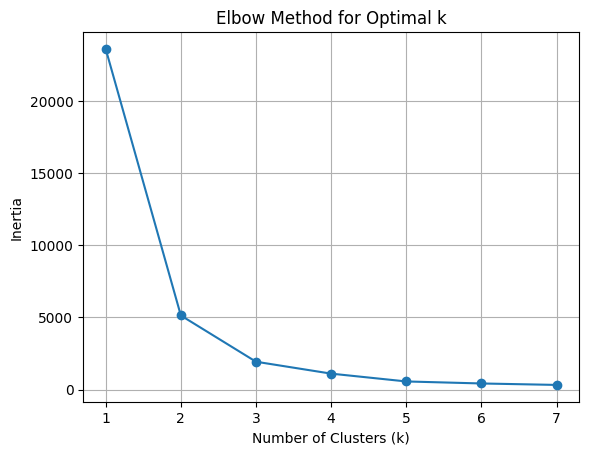

In [7]:
#  Plot the Elbow Curve
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [8]:
# Choose optimal k (from elbow, assume k=3)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
df['Cluster'] = kmeans.fit_predict(df)

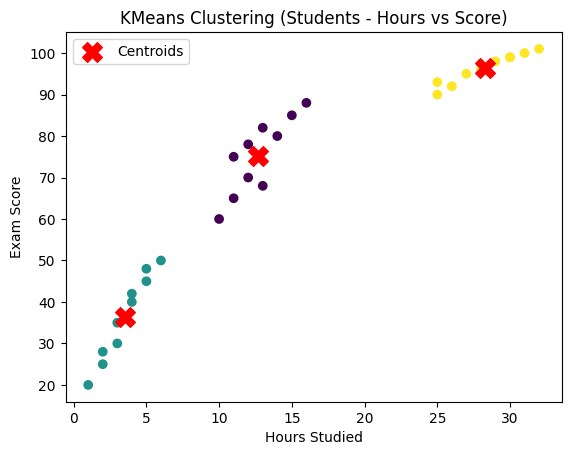

In [9]:
# Visualize Clusters
plt.scatter(df['Hours_Studied'], df['Exam_Score'], c=df['Cluster'], cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title('KMeans Clustering (Students - Hours vs Score)')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()